In [1]:
import cv2
import numpy as np 
import torch
import matplotlib.pyplot as plt

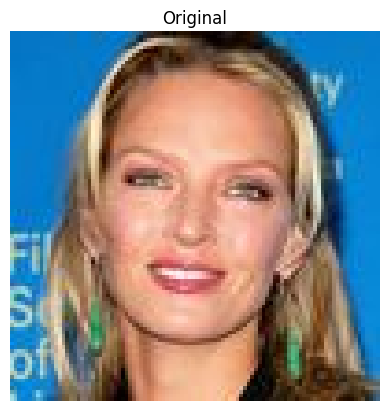

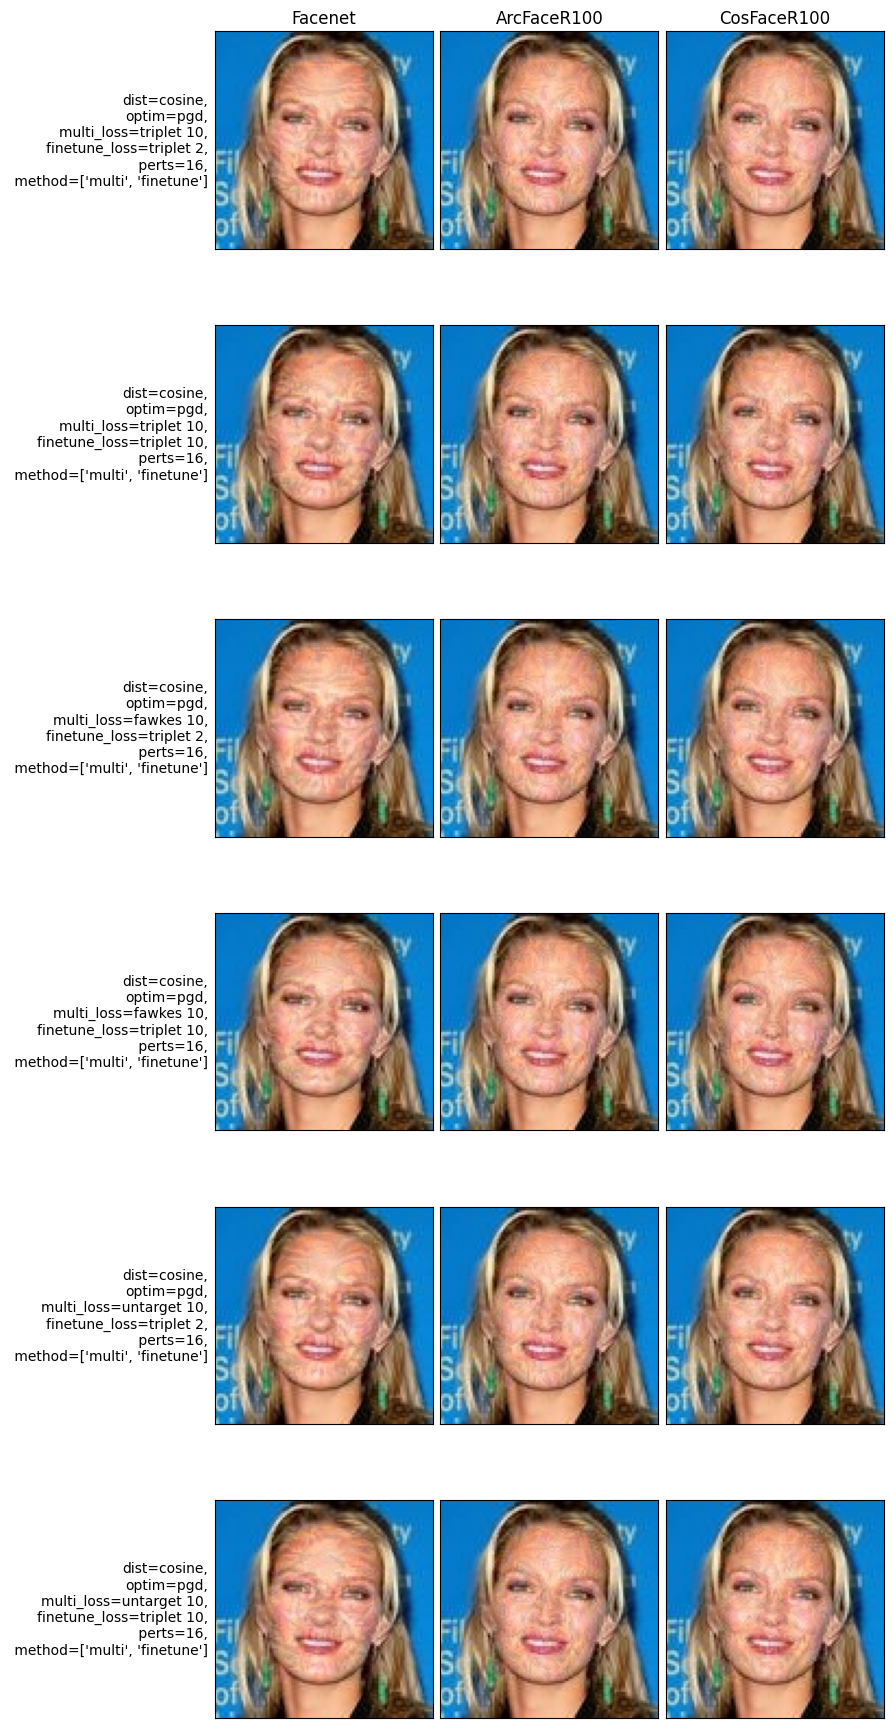

In [56]:
def parse_type(type):
    data = type.split("_")
    data.pop(2)
    parsed_type=f"dist={data[0]},\noptim={data[1]},\nmulti_loss={data[2]} {data[3]},\nfinetune_loss={data[4]} {data[5]},\n perts={data[6]},\n method={data[7:]}"
    return parsed_type

person = "UmaThurman_70.jpg"
dataset = "pubfig_small_flat"
models = ["Facenet", "ArcFaceR100", "CosFaceR100"]
types = ["cosine_pgd_cloak_triplet_10_triplet_2_16_multi_finetune",
        "cosine_pgd_cloak_triplet_10_triplet_10_16_multi_finetune",
        "cosine_pgd_cloak_fawkes_10_triplet_2_16_multi_finetune",
        "cosine_pgd_cloak_fawkes_10_triplet_10_16_multi_finetune",
        "cosine_pgd_cloak_untarget_10_triplet_2_16_multi_finetune",
        "cosine_pgd_cloak_untarget_10_triplet_10_16_multi_finetune"]

im = cv2.imread(f"data/{dataset}/{person}")
im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
plt.imshow(im)
plt.axis('off')
plt.title("Original")
plt.show()


fig, ax = plt.subplots(len(types), len(models), sharex='col', sharey='row', figsize=(3*len(models), 3*len(types)))
for i, type in enumerate(types):
    for j, model in enumerate(models):
        path = f"data/cloaked/cloak_{dataset}_{model}_{type}/{person}"
        im = cv2.imread(path)
        im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
        ax[i, j].set_xticks([])
        ax[i, j].set_yticks([])
        ax[i,j].imshow(im)
        if i == 0:
            ax[i,j].set_title(model)
        if j == 0:
            ax[i,j].set_ylabel(parse_type(type), rotation=0, labelpad=5, va='center', ha='right')

plt.tight_layout()
plt.show()
